In [13]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import pickle 
from scipy.interpolate import interp1d

In [14]:
from __future__ import division

import datetime
import io
import matplotlib as mpl
import matplotlib.patches as patches
import matplotlib.pyplot as plt
import numpy as np
#import obspy
import os
import requests
#import scipy.constants as scc
#import scipy.fftpack as fft
#import scipy.optimize as opt
#import scipy.integrate as scint
#import scipy.interpolate as sctrp
#import scipy.io as scio
#import scipy.signal as sig
#import scipy.special as scsp
import sys
#import tqdm
import warnings
import xml.etree.ElementTree as xmlet

#from astropy import constants as const

"""
This script reads in seismic spectral Probability Density Functions (PDFs) from the MUSTANG database and plots them.
"""

class geoStation:
    def __init__(self, network, station, locations, channels, label=None):
        self.network = network
        self.station = station
        self.locations = locations
        self.channels = channels
        self.label = label
        
#    def get_station_info(self):
#        query_params = {
#            'network': self.network,
#            'station': self.station,
#            }
#       query_url = 'http://service.iris.edu/fdsnws/station/1/query'
#        rr = requests.get(url=query_url, params=query_params)
#        root = xmlet.fromstring(rr.content)
        
    def get_xml_histograms(self, start, stop):
        xml_histograms = []
        for location, channel in zip(self.locations, self.channels):
            query_params={
                'target': '{}.{}.{}.{}.M'.format(self.network, self.station, location, channel),
                'starttime': '{}'.format(start),
                'endtime': '{}'.format(stop),
                'format': 'xml',
                }
            query_url = 'http://service.iris.edu/mustang/noise-pdf/1/query'
            rr = requests.get(url=query_url, params=query_params)
            xml_histograms.append(rr)
        self.xml_histograms = xml_histograms
        
    def get_text_percentiles(self, start, stop):
        text_percentiles = []
        freqs = []
        for location, channel in zip(self.locations, self.channels):
            query_params={
                'target': '{}.{}.{}.{}.M'.format(self.network, self.station, location, channel),
                'starttime': '{}'.format(start),
                'endtime': '{}'.format(stop),
                'format': 'noiseprofile_text',
                'noiseprofile.type': ','.join([str(q) for q in np.arange(0, 101)])
                }
            query_url = 'http://service.iris.edu/mustang/noise-pdf/1/query'
            rr = requests.get(url=query_url, params=query_params)
            text_percentile = np.genfromtxt(io.StringIO(rr.content.decode('ASCII')), delimiter=',', unpack=1)
            text_percentiles.append(10**(text_percentile[1:]/10))
            freqs.append(text_percentile[0])
        self.freqs = freqs
        self.text_percentiles = text_percentiles
        
    def parse_xml_histograms(self, normed=False):
        freqs = []
        acc = []
        acc_histograms = []
        acc_percentiles = []
        for rr in self.xml_histograms:
            root = xmlet.fromstring(rr.content)
            allfreqs = np.array([np.float64(child.attrib['freq']) for child in root[-1]])
            allhits = np.array([np.float64(child.attrib['hits']) for child in root[-1]])
            allpowers = np.array([np.float64(child.attrib['power']) for child in root[-1]])
            uniquefreqs = np.unique(allfreqs)
            uniquepowers = np.unique(allpowers)
            freqs.append(uniquefreqs)
            acc.append(10**(uniquepowers / 10))
            freqs_mesh, powers_mesh = np.meshgrid(uniquefreqs, uniquepowers)
            hits_mesh = np.zeros_like(powers_mesh)
            for freq, hit, power in zip(allfreqs, allhits, allpowers):
                indices = tuple(np.argwhere(np.all([freqs_mesh==freq, powers_mesh==power], axis=0))[0])
                hits_mesh[indices] = hit
            acc_percentile = []
            for freq in uniquefreqs:
                thepowers = allpowers[allfreqs==freq]
                thehits = allhits[allfreqs==freq]
                hist_thehits = np.cumsum(thehits[np.argsort(thepowers)]) / np.sum(thehits) * 100
                percentile_powers = []
                for q in np.arange(0, 101):
                    theargs = np.argwhere(hist_thehits<=q)
                    if len(theargs) == 0:
                        theargs = np.array([0])
                    percentile_powers.append(thepowers[theargs[-1]])
                acc_percentile.append(10**(np.array(percentile_powers, dtype="object")/10))
            acc_percentiles.append(np.array(acc_percentile, dtype="object").T)
            if normed:
                hits_mesh /= np.tile(np.max(hits_mesh, axis=0), (hits_mesh.shape[0], 1))
            acc_histograms.append(hits_mesh)
        self.freqs = freqs
        self.acc = acc
        self.acc_histograms = acc_histograms
        self.acc_percentiles = acc_percentiles

In [15]:
start_date = pd.to_datetime('2008-01-01',format='%Y-%m-%d')
end_date = pd.to_datetime('2024-06-01',format='%Y-%m-%d')


In [16]:
from datetime import datetime, timedelta
from time import sleep

# Get seismic spectra

# OOI Axial Seamount
# OO_AXAS1 = geoStation('OO', 'AXAS1', ['--'], ['SHZ'], label='RSN Axial Ashes 1')
# station_list = [OO_AXAS1]

# OO_AXAS1 = geoStation('OO', 'AXAS1', ['--'], ['SHZ'], label='RSN Axial Ashes 1')
# OO_AXAS2 = geoStation('OO', 'AXAS2', ['--'], ['SHZ'], label='RSN Axial Ashes 2')
# OO_AXEC1 = geoStation('OO', 'AXEC1', ['--'], ['SHZ'], label='RSN Axial East Caldera 1')
# OO_AXEC3 = geoStation('OO', 'AXEC3', ['--'], ['SHZ'], label='RSN Axial East Caldera 3')
# OO_AXID1 = geoStation('OO', 'AXID1', ['--'], ['SHZ'], label='RSN Axial International')
# station_list = [OO_AXAS1, OO_AXAS2, OO_AXEC1, OO_AXEC3, OO_AXID1]

# # Ely, Minnesota, USA
# comp = ['BHZ']
# US_EYMN = geoStation('US', 'EYMN', ['**'], comp, label='Ely, Minnesota, USA')
# station_list = [US_EYMN]

# # Erie, Pennsylvania, USA
# comp = ['BHZ']
# US_ERPA = geoStation('US', 'ERPA', ['**'], comp, label='Erie, Pennsylvania, USA')
# station_list = [US_ERPA]

# Sadowa, ON, CA
comp = ['BHZ']
CN_SADO = geoStation('CN', 'SADO', ['**'], comp, label='Sadowa, ON, CA')
station_list = [CN_SADO]

dof = 0
# plotunit = 2 # 2=acceleration, 1=velocity, 0=displacement
plotunit = 2 # 2=acceleration, 1=velocity, 0=displacement

# Vector of datetimes spaced every 24 hours
# datevec = np.arange(df['date'].dt.round('1d').min(),df['date'].dt.round('1d').max(), timedelta(days=1))
# datevec = df['date'].to_numpy()
# datevec_end = np.append(df['date'][1:].to_numpy(),(df['date'][-1]+(df['date'][-1]-df['date'][-2])).to_numpy())
dt_days = 8
datevec = np.arange(start_date,end_date, timedelta(days=dt_days))

pd.options.mode.chained_assignment = None  # default='warn' suppress annoying warning
for station in station_list:
    # Get average noise properties
    PSD_avg = 0
    PSDs = []
    icnt = 0
    freqs = np.array([])
    for iday in range(len(datevec)):
        tstart = datevec[iday] - np.timedelta64(int(dt_days/2),'D') #- timedelta(1) # -24 hours
        tend = datevec[iday] + np.timedelta64(int(dt_days/2),'D') # +24 hours
        # tend = datevec_end[iday]

        tstart_str = tstart.astype('datetime64[s]').item().strftime('%Y-%m-%d')
        tend_str = tend.astype('datetime64[s]').item().strftime('%Y-%m-%d')

        print('Working on '+tstart_str+' to '+tend_str)

        try:
            station.get_xml_histograms(tstart_str, tend_str)
            station.get_text_percentiles(tstart_str, tend_str)
        except:
            print('IRIS unhappy... trying again')
            sleep(2)
            station.get_xml_histograms(tstart_str, tend_str)
            station.get_text_percentiles(tstart_str, tend_str)
        
        if len(station.text_percentiles[dof]) < 50:
            print('Missing '+tstart_str+' trying HHZ component')
            sleep(2)
            station.channels = [c.replace('B','H') for c in station.channels]
            station.get_xml_histograms(tstart_str, tend_str)
            station.get_text_percentiles(tstart_str, tend_str)

            # Switch back to BHZ
            station.channels = comp

            if len(station.text_percentiles[dof]) < 50:
                print('skipping '+tstart_str)

                PSDs.append(np.nan*np.ones(freqs.shape))
                continue
            
            # # Interpolate to same frequency axis
            # station.text_percentiles[dof] = interp1d(station.freqs[dof],station.text_percentiles[dof])(freqs)

        else:
            if freqs.size == 0:
                # print('saving freqs')
                freqs = station.freqs[dof]

        if station.freqs[dof].size != freqs.size:
            # Interpolate to same frequency axis
            station.text_percentiles[dof] = interp1d(station.freqs[dof],station.text_percentiles[dof])(freqs)
        
        PSD = 10*np.log10(station.text_percentiles[dof][50]/(2*np.pi*freqs)**(2-plotunit))

        PSDs.append(PSD)
        
        PSD_avg = PSD_avg + PSD
        icnt+=1

    PSD_avg = PSD_avg / icnt
    PSDs = np.asarray(PSDs)

    # Save pkl file of PSD spectrogram
    fs,ts = np.meshgrid(freqs,datevec)

    # Create a variable 
    data_PSDs = {'PSD': PSDs, 'ts': ts, 'fs': fs, 'freqs': freqs, 'datevec': datevec,
                 'station': station.station, 'network':station.network, 'comp':station.channels[dof],
                 'label': station.label}

    filename = './PSDs/PSD_'+station.network+'_'+station.station+'_'+station.channels[dof]+'_'+start_date.strftime('%Y%m%d')+'_'+end_date.strftime('%Y%m%d')+'_dt'+str(int(dt_days))+'days.pkl'

    # Open a file and use dump() 
    with open(filename, 'wb') as file: 
        # A new file will be created 
        pickle.dump(data_PSDs, file)


Working on 2007-12-28 to 2008-01-05
Working on 2008-01-05 to 2008-01-13
Working on 2008-01-13 to 2008-01-21
Working on 2008-01-21 to 2008-01-29
Working on 2008-01-29 to 2008-02-06
Working on 2008-02-06 to 2008-02-14
Working on 2008-02-14 to 2008-02-22
Working on 2008-02-22 to 2008-03-01
Working on 2008-03-01 to 2008-03-09
Working on 2008-03-09 to 2008-03-17
Working on 2008-03-17 to 2008-03-25
Working on 2008-03-25 to 2008-04-02
Working on 2008-04-02 to 2008-04-10
Working on 2008-04-10 to 2008-04-18
Working on 2008-04-18 to 2008-04-26
Working on 2008-04-26 to 2008-05-04
Working on 2008-05-04 to 2008-05-12
Working on 2008-05-12 to 2008-05-20
Working on 2008-05-20 to 2008-05-28
Working on 2008-05-28 to 2008-06-05
Working on 2008-06-05 to 2008-06-13
Working on 2008-06-13 to 2008-06-21
Working on 2008-06-21 to 2008-06-29
Working on 2008-06-29 to 2008-07-07
Working on 2008-07-07 to 2008-07-15
Working on 2008-07-15 to 2008-07-23
Working on 2008-07-23 to 2008-07-31
Working on 2008-07-31 to 200

ConnectTimeout: HTTPConnectionPool(host='service.iris.edu', port=80): Max retries exceeded with url: /mustang/noise-pdf/1/query?target=CN.SADO.%2A%2A.HHZ.M&starttime=2022-01-27&endtime=2022-02-04&format=noiseprofile_text&noiseprofile.type=0%2C1%2C2%2C3%2C4%2C5%2C6%2C7%2C8%2C9%2C10%2C11%2C12%2C13%2C14%2C15%2C16%2C17%2C18%2C19%2C20%2C21%2C22%2C23%2C24%2C25%2C26%2C27%2C28%2C29%2C30%2C31%2C32%2C33%2C34%2C35%2C36%2C37%2C38%2C39%2C40%2C41%2C42%2C43%2C44%2C45%2C46%2C47%2C48%2C49%2C50%2C51%2C52%2C53%2C54%2C55%2C56%2C57%2C58%2C59%2C60%2C61%2C62%2C63%2C64%2C65%2C66%2C67%2C68%2C69%2C70%2C71%2C72%2C73%2C74%2C75%2C76%2C77%2C78%2C79%2C80%2C81%2C82%2C83%2C84%2C85%2C86%2C87%2C88%2C89%2C90%2C91%2C92%2C93%2C94%2C95%2C96%2C97%2C98%2C99%2C100 (Caused by ConnectTimeoutError(<urllib3.connection.HTTPConnection object at 0x1a30b3d50>, 'Connection to service.iris.edu timed out. (connect timeout=None)'))

(0.1, 10)

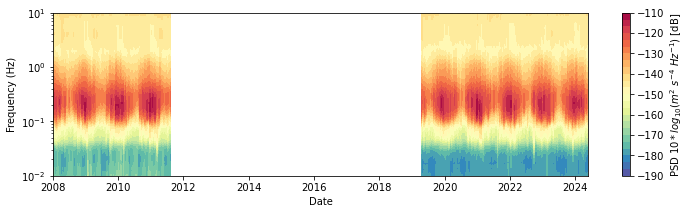

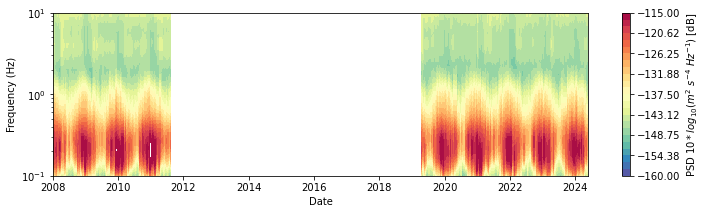

In [ ]:
# Plot spectrogram of seismic noise

fig = plt.figure(figsize=(12,3))
ax = plt.axes()
levels = np.linspace(-190,-110,25)
c = ax.contourf(ts,fs,PSDs,levels=levels, vmin=levels.min(), vmax=levels.max(), cmap='Spectral_r')
cb = plt.colorbar(c)
cb.set_label(r'PSD $10*log_{10}(m^2 \,\, s^{-4} \,\, Hz^{-1})$ [dB]')
ax.set_yscale('log')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Date')
ax.set_ylim(1/100,10)

fig = plt.figure(figsize=(12,3))
ax = plt.axes()
levels = np.linspace(-160,-115,25)
c = ax.contourf(ts,fs,PSDs,levels=levels, vmin=levels.min(), vmax=levels.max(), cmap='Spectral_r')
cb = plt.colorbar(c)
cb.set_label(r'PSD $10*log_{10}(m^2 \,\, s^{-4} \,\, Hz^{-1})$ [dB]')
ax.set_yscale('log')
ax.set_ylabel('Frequency (Hz)')
ax.set_xlabel('Date')
ax.set_ylim(1/10,10)

Text(0, 0.5, 'PSD $10*log_{10}(m^2 s^{-4} Hz^{-1})$ [dB]')

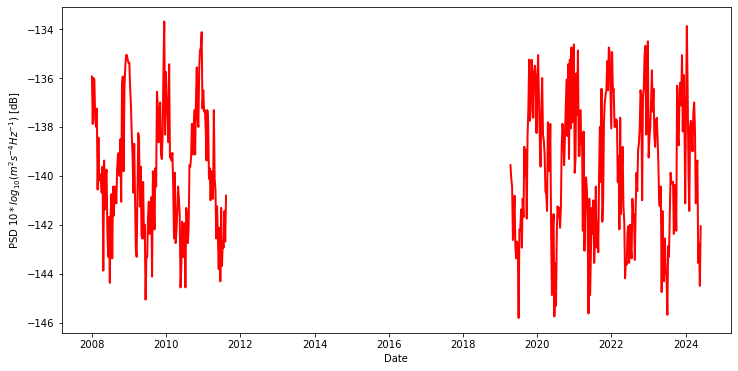

In [ ]:
import scipy

# Calculate power within frequency band

# Define fmin and fmax
fmin = 0.5 #1/3
fmax = 2 #1/0.65
# fmin = 0.2*2
# fmax = 0.4*2
# fmin = 1/10
# fmax = 1
# fmin = 1
# fmax = 2

PSD_band = PSDs[:,(freqs>=fmin) & (freqs<=fmax)].mean(axis=1)

fig = plt.figure(figsize=(12,6))
ax = plt.axes()
ax.plot(datevec, PSD_band, '-', c='r', lw=2)
ax.set_ylabel(str(fmin)+'-'+str(fmax)+' Hz Seismic Noise (dB)', color='k')

ax.set_xlabel('Date')
ax.set_ylabel(r'PSD $10*log_{10}(m^2 s^{-4} Hz^{-1})$ [dB]')
